In [1]:
import sys 
sys.path.append('../')
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

In [2]:
device = torch.device('cpu')
# model = torch.load('../results/cosine/MLNO-vanilla/exp-2023-12-18-13-34-27/model_best_operator.pth').to(device)
model = torch.load('../results/logarithm/MLNO-vanilla/exp-2023-12-19-08-56-06/model_best_operator.pth').to(device)

In [3]:
l = 9
n = 2**l+1
x = torch.linspace(-1,1,2*n-1)[None][None].to(device)

In [4]:
n = x.shape[-1]
k = model.neural_kernel(x)
k[:,:,(n-1)//2-model.m:(n-1)//2+model.m+1] += model.band_corr1(x[:,:,(n-1)//2-model.m:(n-1)//2+model.m+1])
k = k.detach()
# k_corr1 = F.relu(model.band_corr1(x[:,:,(n-1)//2-31:(n-1)//2+32])).detach().cpu()
# k_corr2 = F.relu(model.band_corr2(x[:,:,(n-1)//2-15:(n-1)//2+16])).detach().cpu()
# k_corr3 = F.relu(model.band_corr3(x[:,:,(n-1)//2-7:(n-1)//2+8])).detach().cpu()

# k_c1 = k_smooth.clone()
# k_c1[:,:,(n-1)//2-31:(n-1)//2+32] += k_corr1

# k_c2 = k_c1.clone()
# k_c2[:,:,(n-1)//2-15:(n-1)//2+16] += k_corr2

# k_c3 = k_c2.clone()
# k_c3[:,:,(n-1)//2-7:(n-1)//2+8] += k_corr3

In [5]:
x[:,:,(n-1)//2-model.m:(n-1)//2+model.m+1]

tensor([[[-0.0137, -0.0117, -0.0098, -0.0078, -0.0059, -0.0039, -0.0020,
           0.0000,  0.0020,  0.0039,  0.0059,  0.0078,  0.0098,  0.0117,
           0.0137]]])

In [6]:
model.band_corr1(x)[0,0]

tensor([0.0016, 0.0016, 0.0016,  ..., 0.0342, 0.0342, 0.0343],
       grad_fn=<SelectBackward0>)

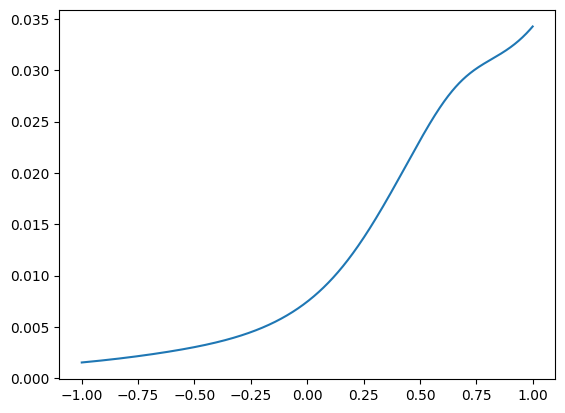

In [7]:
plt.plot(x[0,0], model.band_corr1(x)[0,0].detach())

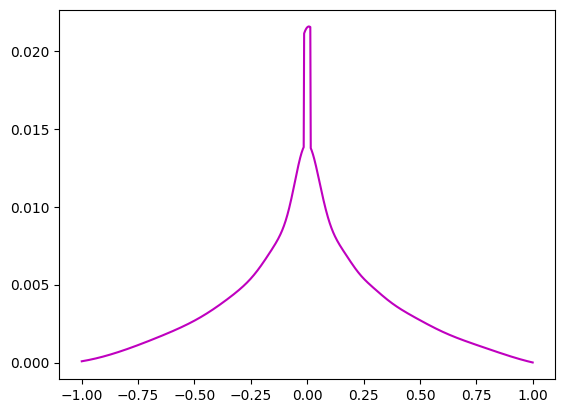

In [8]:
plt.plot(x[0,0], k[0,0], '-m')
# plt.plot(x[0,0,(n-1)//2-31:(n-1)//2+32], k_corr1[0,0], '-r')
# plt.plot(x[0,0,(n-1)//2-15:(n-1)//2+16], k_corr2[0,0], '-b')
# plt.plot(x[0,0,(n-1)//2-7:(n-1)//2+8], k_corr3[0,0], '-g')

/tmp/ipykernel_841137/68862561.py:2: RuntimeWarning: divide by zero encountered in log
  plt.plot(x[0,0], np.nan_to_num(-np.log(x[0,0].abs()), posinf=7), '--r')


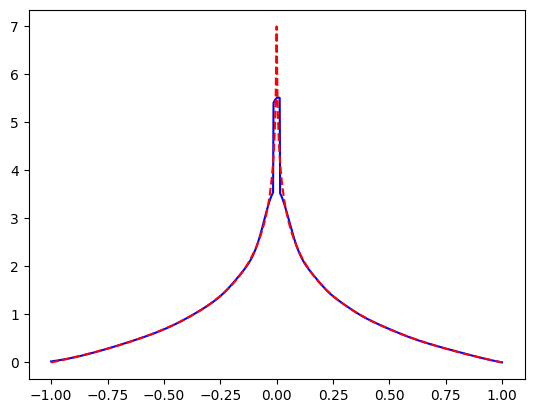

In [9]:
plt.plot(x[0,0], k[0,0]*2**8, '-b')
plt.plot(x[0,0], np.nan_to_num(-np.log(x[0,0].abs()), posinf=7), '--r')
# plt.plot(x[0,0], k_c1[0,0]*2**8, '-y')
# plt.plot(x[0,0], k_c2[0,0]*2**8, '-g')
# plt.plot(x[0,0], k_c3[0,0]*2**8, '-m')
# plt.yscale('log')

In [55]:
import pandas as pd

In [61]:
loss_hist = pd.read_csv('../results/cosine/MLNO-vanilla/exp-2023-12-18-13-34-27/hist.csv')
loss_hist = pd.read_csv('../results/logarithm/MLNO-vanilla/exp-2023-12-18-13-30-58/hist.csv')

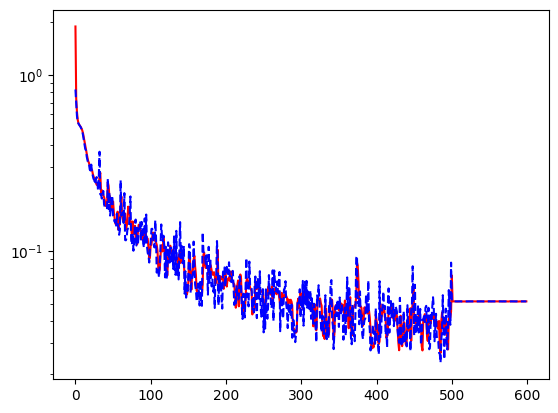

In [62]:
plt.plot(loss_hist.train_rl2, '-r')
plt.plot(loss_hist.test_rl2, '--b')
plt.yscale('log')